<a href="https://colab.research.google.com/github/binhminh276/hcmc-house-price-prediction-2stage/blob/main/notebooks/10_EDA_additional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("official_ChiTiet_BDS_LocTruong.csv")
df

,Diện tích,Số phòng ngủ,"Số phòng tắm, vệ sinh",Pháp lý,Nội thất,Mặt tiền,Gần bệnh viện,Gần chợ,Gần trường học,Cao tầng,Quy hoạch,Phường,Quận,Giá m2,Cluster
0,54.0,3,4,Không rõ,Không rõ,0,0,0,0,1,0,Phường 5,Gò Vấp,0.157407,1
1,28.4,3,3,Sổ riêng,Nội thất cơ bản,1,1,1,0,1,0,Phường 4,Quận 1,0.246479,1
2,69.0,3,3,Sổ riêng,Không rõ,1,0,1,1,1,0,Phường Long Phước,Thủ Đức,0.047826,1
3,78.2,3,3,Sổ riêng,Không rõ,1,0,0,0,1,0,Phường Trường Thọ,Thủ Đức,0.088875,1
4,75.9,2,2,Sổ riêng,Không rõ,1,0,0,0,0,1,Phường Linh Tây,Thủ Đức,0.088274,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11225,71.0,3,3,Không rõ,Không rõ,0,0,0,0,1,0,Phường 16,Gò Vấp,0.097183,1
11226,81.1,4,6,Sổ riêng,Full nội thất,0,0,1,1,0,0,Phường Thới An,Quận 1,0.088163,1
11227,23.0,2,3,Sổ riêng,Không rõ,0,1,1,0,1,1,Phường Linh Xuân,Thủ Đức,0.108696,1
11228,100.0,4,3,Sổ riêng,Không rõ,1,0,0,0,1,0,Phường 14,Phú Nhuận,0.185000,1


In [2]:
df["Giá m2 (triệu)"] = df["Giá m2"] * 1000
df[["Giá m2", "Giá m2 (triệu)"]].head()

,Giá m2,Giá m2 (triệu)
0,0.157407,157.407
1,0.246479,246.479
2,0.047826,47.826
3,0.088875,88.875
4,0.088274,88.274


### Phân phối của biến mục tiêu

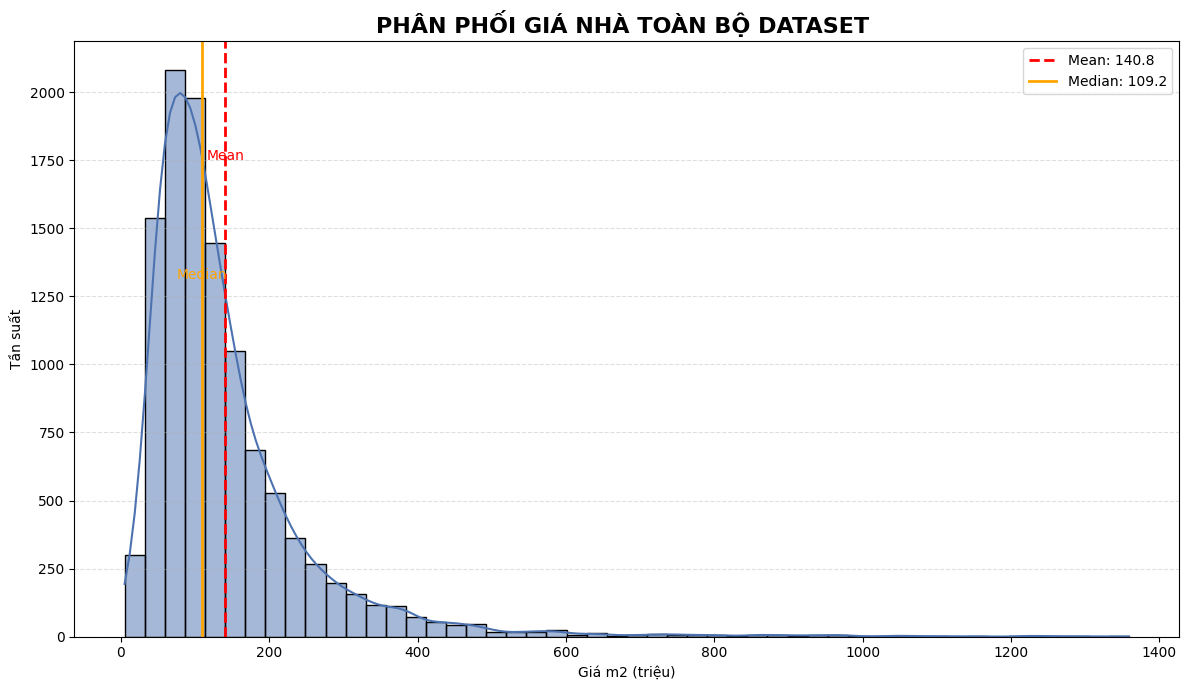

In [3]:
# Histogram + KDE + Mean & Median line
plt.figure(figsize=(12,7))
data = df['Giá m2 (triệu)']
mean_val = data.mean()
median_val = data.median()
sns.histplot(data, bins=50, kde=True, color="#4C72B0", edgecolor="black")

# Vẽ mean & median
plt.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.1f}")
plt.axvline(median_val, color="orange", linestyle="-", linewidth=2, label=f"Median: {median_val:.1f}")

# Annotation
plt.text(mean_val, plt.ylim()[1]*0.8, "Mean", color="red", ha='center')
plt.text(median_val, plt.ylim()[1]*0.6, "Median", color="orange", ha='center')

plt.title("PHÂN PHỐI GIÁ NHÀ TOÀN BỘ DATASET ", fontsize=16, fontweight="bold")
plt.xlabel("Giá m2 (triệu)")
plt.ylabel("Tần suất")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

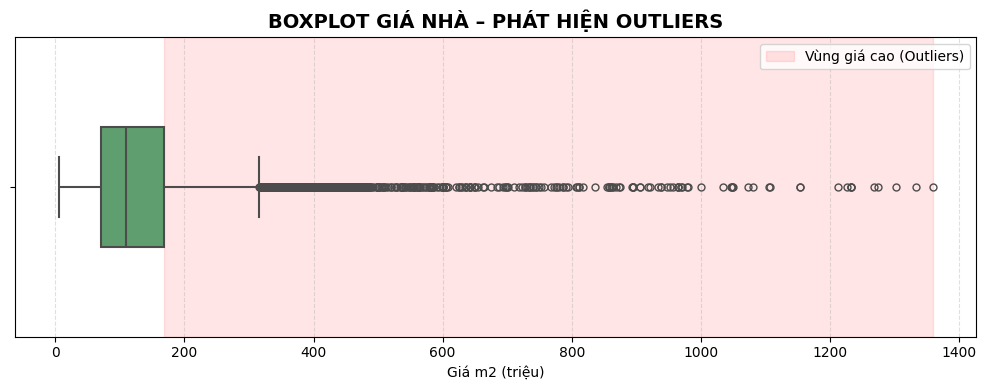

In [4]:
# Boxplot
plt.figure(figsize=(10,4))
sns.boxplot(
    x=data,
    color="#55A868",
    width=0.4,
    fliersize=5,
    linewidth=1.5
)

# Highlight outliers vùng phải
plt.axvspan(np.percentile(data, 75), data.max(), color="red", alpha=0.1, label="Vùng giá cao (Outliers)")
plt.title("BOXPLOT GIÁ NHÀ – PHÁT HIỆN OUTLIERS", fontsize=14, fontweight="bold")
plt.xlabel("Giá m2 (triệu)")
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

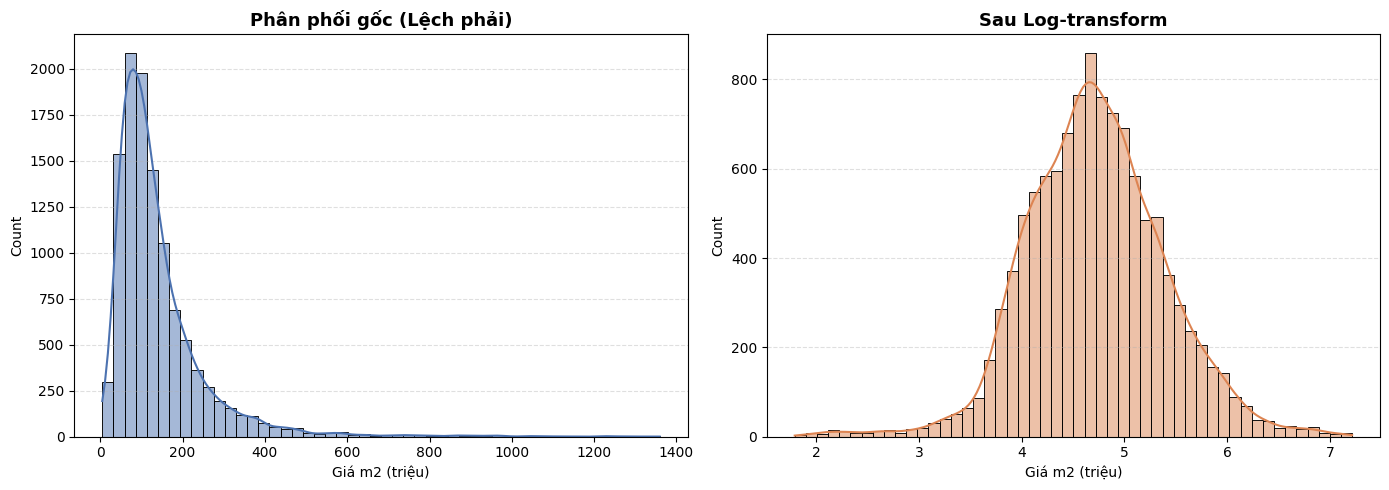

In [5]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

# Original
sns.histplot(data, bins=50, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Phân phối gốc (Lệch phải)", fontsize=13, fontweight="bold")

# Log
log_data = np.log1p(data)
sns.histplot(log_data, bins=50, kde=True, ax=axes[1], color="#DD8452")
axes[1].set_title("Sau Log-transform", fontsize=13, fontweight="bold")

for ax in axes:
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [6]:
mean_val = data.mean()
median_val = data.median()
skew_val = data.skew()
std_val = data.std()

summary_df = pd.DataFrame({
    "Chỉ số": ["Mean", "Median", "Std", "Skewness"],
    "Giá trị": [mean_val, median_val, std_val, skew_val]
})

print(summary_df)

print("\n--- NHẬN XÉT ---")
if skew_val > 0:
    print("→ Phân phối lệch phải (Right-skewed)")
elif skew_val < 0:
    print("→ Phân phối lệch trái")
else:
    print("→ Phân phối đối xứng")

if mean_val > median_val:
    print("→ Mean > Median → xác nhận lệch phải")

     Chỉ số     Giá trị
0      Mean  140.836574
1    Median  109.189500
2       Std  117.653393
3  Skewness    3.468841

--- NHẬN XÉT ---
→ Phân phối lệch phải (Right-skewed)
→ Mean > Median → xác nhận lệch phải


### Phân tích nhóm đặc trưng Vị trí và Kết cấu (Quận, Phường, Mặt tiền, Cao tầng)
→ Ảnh hưởng theo vị trí, theo kết cấu

/tmp/ipykernel_4695/2557372220.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df["Quận"], rotation=75)


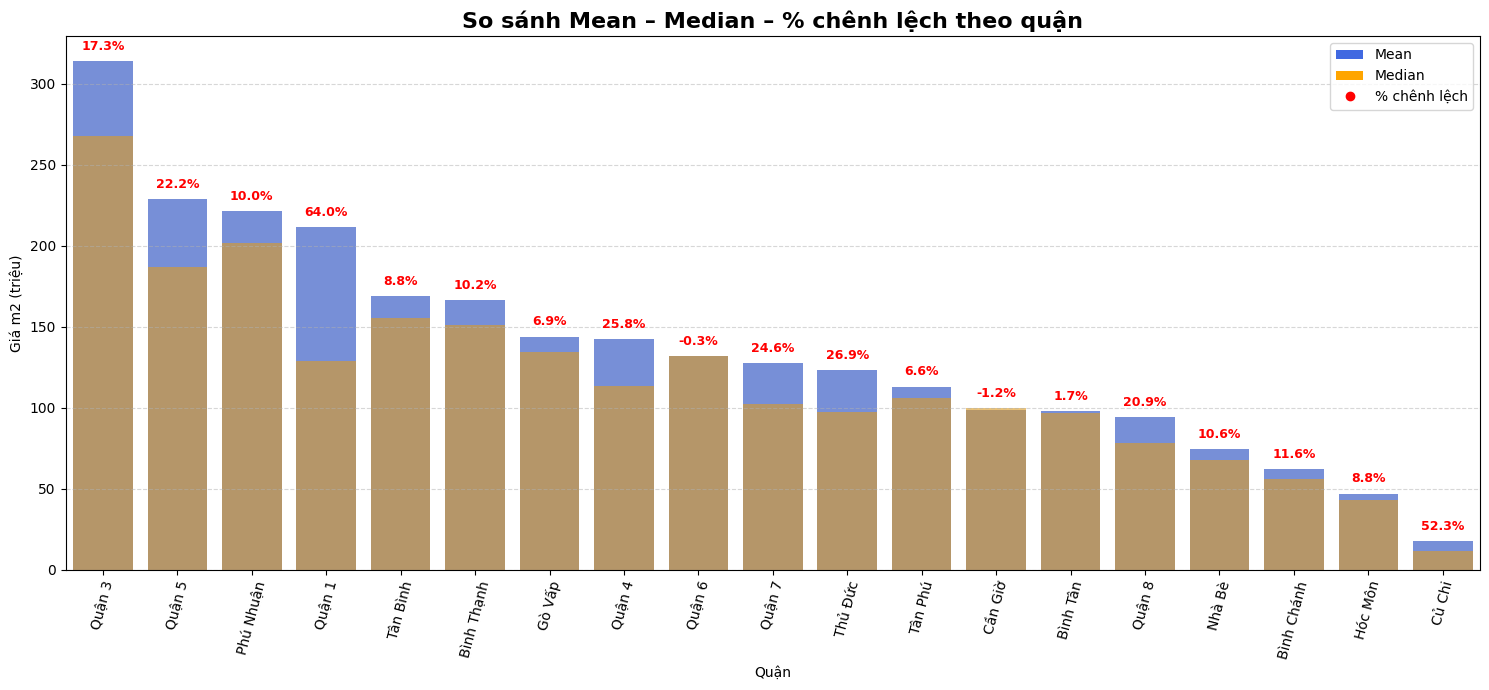

In [10]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
stats_by_district = df.groupby('Quận')['Giá m2 (triệu)'] \
    .agg(['mean', 'median', 'std', 'count', 'max', 'min']) \
    .sort_values(by='mean', ascending=False)

stats_by_district["Chêch lệch (%)"] = (
    (stats_by_district["mean"] - stats_by_district["median"])
    / stats_by_district["median"] * 100
)

plot_df = stats_by_district.reset_index()
fig, ax = plt.subplots(figsize=(15,7))

sns.barplot(data=plot_df, x="Quận", y="mean", color="royalblue", alpha=0.8, ax=ax)
sns.barplot(data=plot_df, x="Quận", y="median", color="orange", alpha=0.6, ax=ax)

ax.set_ylabel("Giá m2 (triệu)")
ax.set_xticklabels(plot_df["Quận"], rotation=75)
ax.set_title("So sánh Mean – Median – % chênh lệch theo quận", fontsize=16, fontweight="bold")

for i in range(len(plot_df)):
    mean_val = plot_df["mean"][i]
    median_val = plot_df["median"][i]
    diff = plot_df["Chêch lệch (%)"][i]

    # đặt text trên cột cao hơn (mean)
    y_pos = max(mean_val, median_val) + 5

    ax.text(
        i,
        y_pos,
        f"{diff:.1f}%",
        ha='center',
        va='bottom',
        fontsize=9,
        color="red",
        fontweight="bold"
    )

legend_elements = [
    Patch(facecolor="royalblue", label="Mean"),
    Patch(facecolor="orange", label="Median"),
    Line2D([0], [0], color="red", marker="o", linestyle='None', label="% chênh lệch")
]
ax.legend(handles=legend_elements, loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

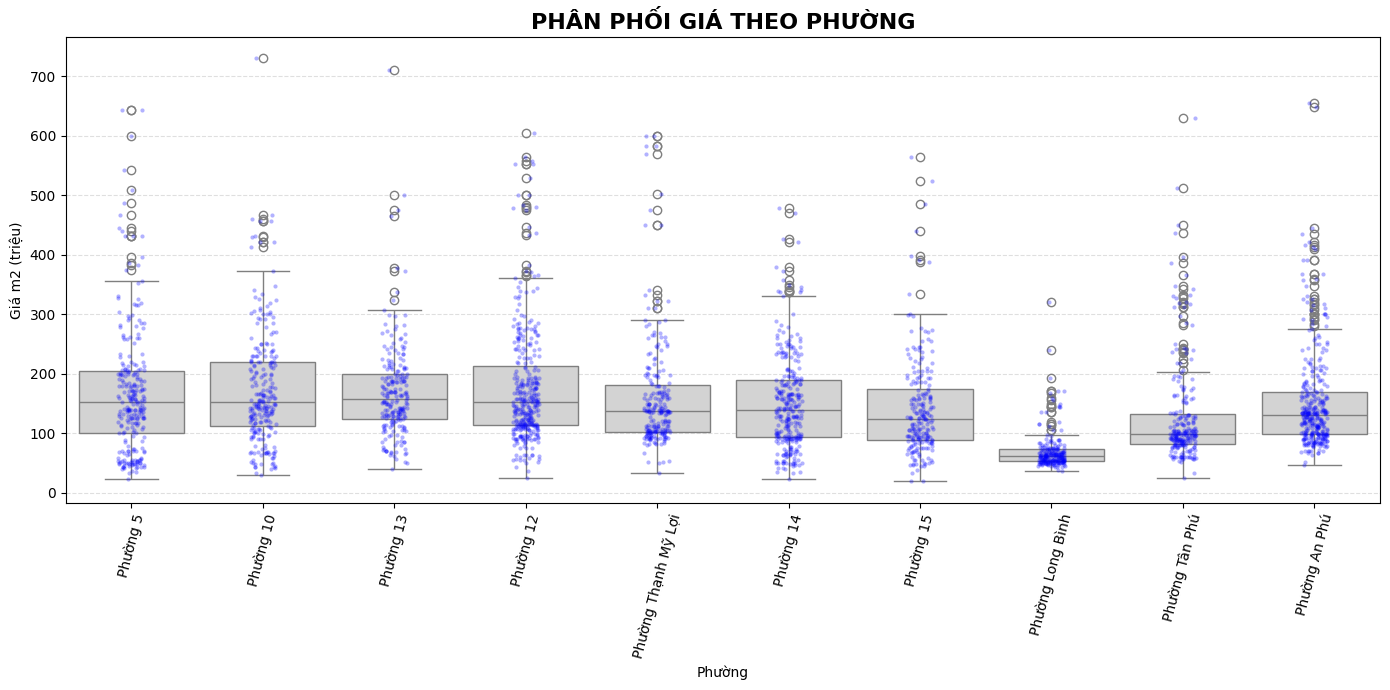

In [11]:
# Vẽ biểu đồ phân phối giá theo phường
top_phuong = df['Phường'].value_counts().head(10).index
df_top = df[df['Phường'].isin(top_phuong)]

plt.figure(figsize=(14,7))
sns.boxplot(
    data=df_top,
    x='Phường',
    y='Giá m2 (triệu)',
    color='lightgray'
)

sns.stripplot(
    data=df_top,
    x='Phường',
    y='Giá m2 (triệu)',
    color='blue',
    size=3,
    alpha=0.3
)

plt.xticks(rotation=75)
plt.title("PHÂN PHỐI GIÁ THEO PHƯỜNG", fontsize=16, fontweight="bold")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4695/3638557654.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


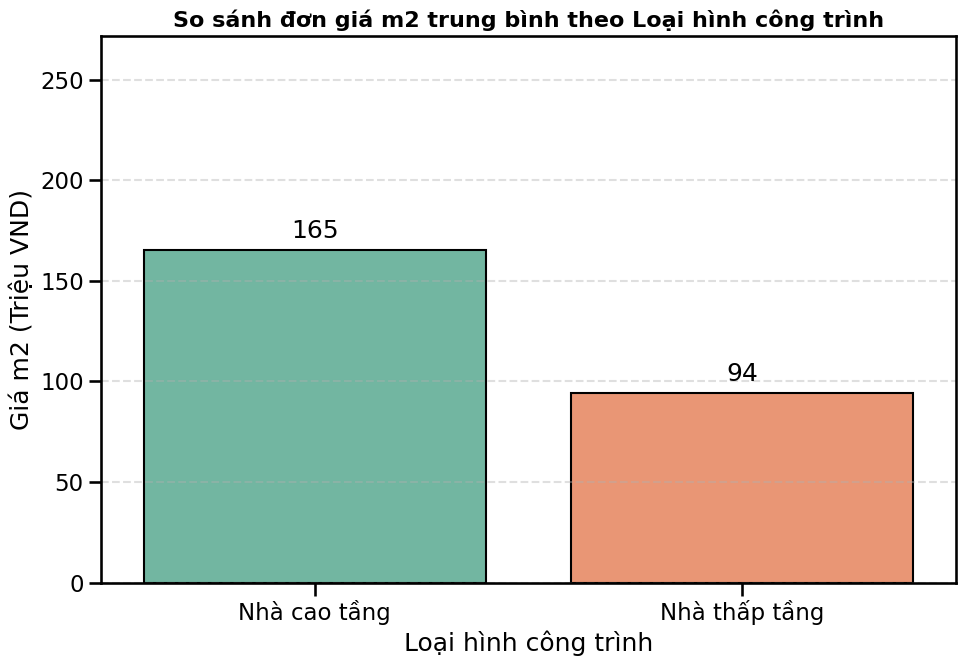

                 mean  median     std  count
Loại hình                                   
Nhà cao tầng   165.31  130.44  128.94   7373
Nhà thấp tầng   94.06   76.28   72.06   3857


In [12]:
# Vẽ biều đồ loại hình nhà
df_type = df.dropna(subset=['Cao tầng', 'Giá m2 (triệu)']).copy()

# Mapping loại hình
df_type['Loại hình'] = df_type['Cao tầng'].map({ 0: 'Nhà thấp tầng', 1: 'Nhà cao tầng'})

plt.figure(figsize=(10, 7))
sns.set_context("talk")
ax = sns.barplot(
    x='Loại hình',
    y='Giá m2 (triệu)',
    data=df_type,
    palette='Set2',
    errorbar=None,
    edgecolor='black'
)

plt.title('So sánh đơn giá m2 trung bình theo Loại hình công trình',
          fontsize=16, fontweight='bold')
plt.xlabel('Loại hình công trình')
plt.ylabel('Giá m2 (Triệu VND)')

ax.set_ylim(0, df_type['Giá m2 (triệu)'].max() * 0.2)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 5),
                textcoords='offset points')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Thống kê
stats = df_type.groupby('Loại hình')['Giá m2 (triệu)'] \
    .agg(['mean', 'median', 'std', 'count']) \
    .round(2)

print(stats)

<Figure size 1600x900 with 0 Axes>

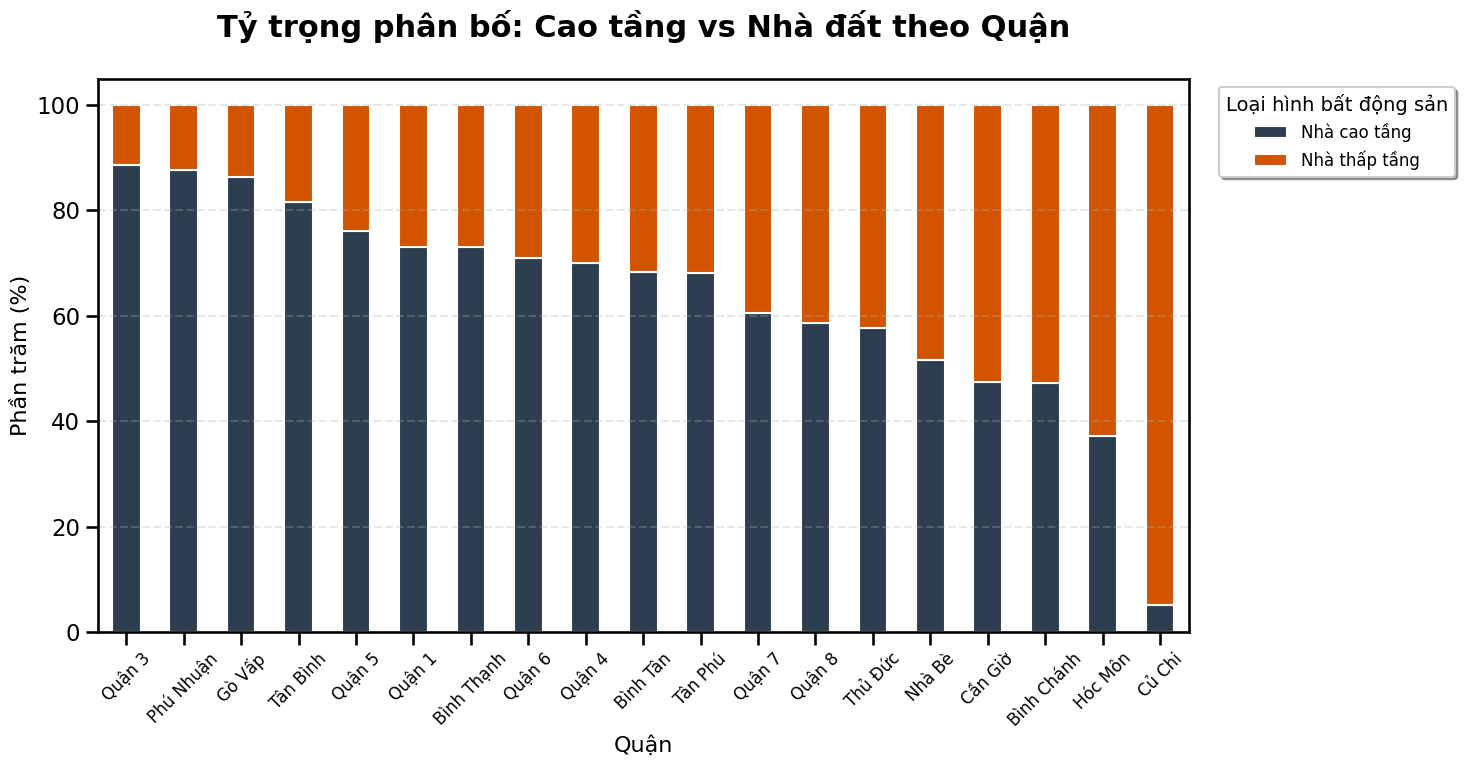

Top 5 Quận có tỷ lệ Cao tầng cao nhất:
Loại hình  Nhà cao tầng  Nhà thấp tầng
Quận                                  
Quận 3            88.60          11.40
Phú Nhuận         87.62          12.38
Gò Vấp            86.28          13.72
Tân Bình          81.57          18.43
Quận 5            76.19          23.81


In [13]:
# Vẽ biểu đ tỷ trọng phân bố Nhà Cao tầng vs Nhà đất theo Quận
df_plot = df.dropna(subset=['Cao tầng', 'Quận']).copy()
df_plot['Loại hình'] = df_plot['Cao tầng'].map({0: 'Nhà thấp tầng', 1: 'Nhà cao tầng'})
dist_type_counts = pd.crosstab(df_plot['Quận'], df_plot['Loại hình'])
dist_type_pct = dist_type_counts.div(dist_type_counts.sum(axis=1), axis=0) * 100

if 'Nhà cao tầng' in dist_type_pct.columns:
    dist_type_pct = dist_type_pct.sort_values(by='Nhà cao tầng', ascending=False)
plt.figure(figsize=(16, 9))
sns.set_context("talk")
colors = ['#2c3e50', '#d35400']
ax = dist_type_pct.plot(kind='bar', stacked=True, figsize=(15, 8), color=colors, edgecolor='white')

plt.title('Tỷ trọng phân bố: Cao tầng vs Nhà đất theo Quận', fontsize=22, fontweight='bold', pad=30)
plt.ylabel('Phần trăm (%)', fontsize=16)
plt.xlabel('Quận', fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.legend(title='Loại hình bất động sản',
           bbox_to_anchor=(1.02, 1),
           loc='upper left',
           fontsize=12,
           title_fontsize=14,
           frameon=True,
           shadow=True)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 Quận có tỷ lệ Cao tầng cao nhất:")
print(dist_type_pct.head(5).round(2))

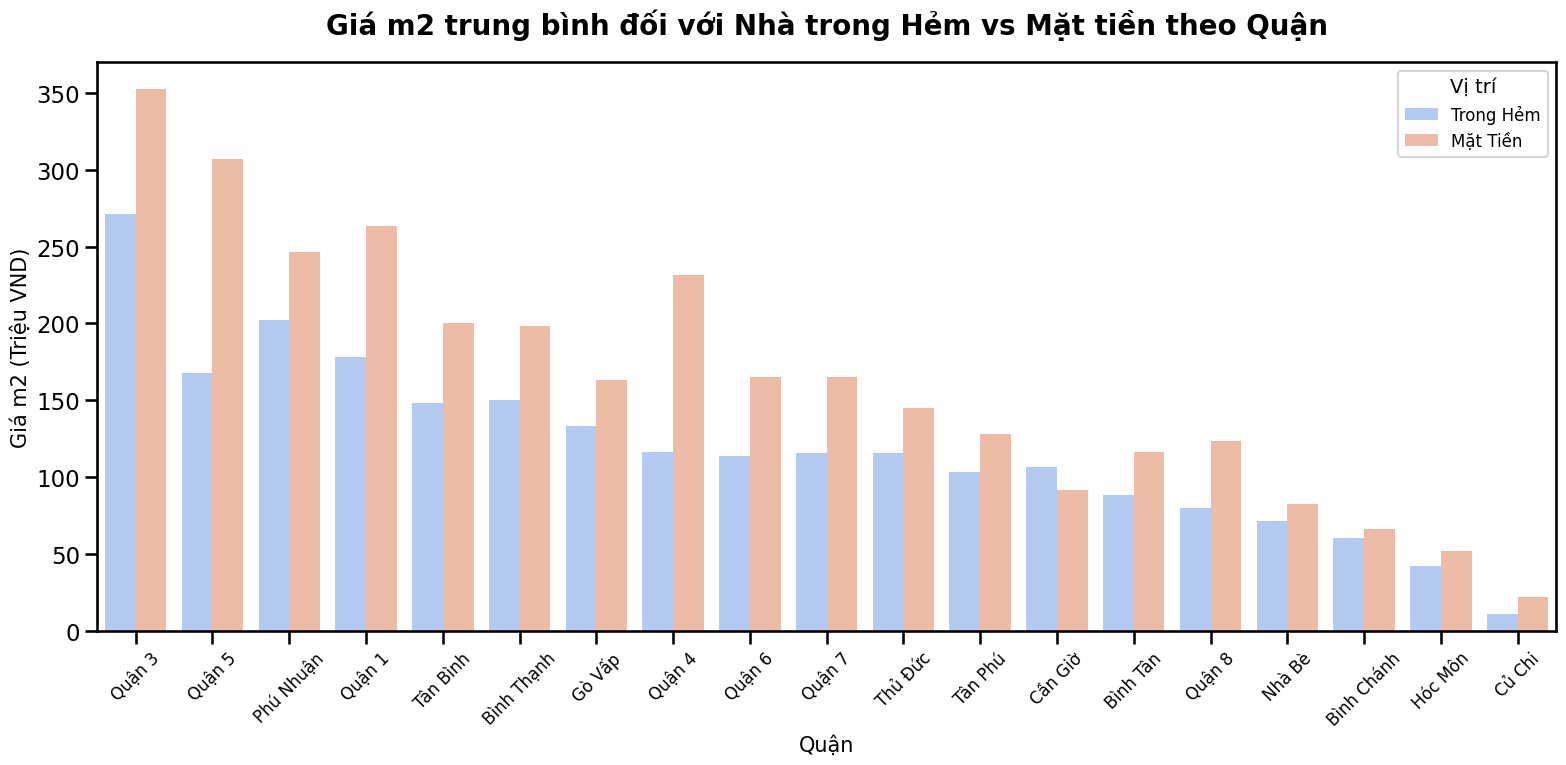

In [14]:
# Vẽ biểu đồ phân phối Nhà hẻm và Mặt tiền theo Quận
plt.figure(figsize=(16, 8))
sns.set_context("talk")
district_order = df.groupby('Quận')['Giá m2 (triệu)'].mean().sort_values(ascending=False).index
ax = sns.barplot(
    x='Quận',
    y='Giá m2 (triệu)',
    hue='Mặt tiền',
    data=df,
    order=district_order,
    palette='coolwarm',
    errorbar=None
)

plt.title('Giá m2 trung bình đối với Nhà trong Hẻm vs Mặt tiền theo Quận', fontsize=20, fontweight='bold', pad=20)
plt.ylabel('Giá m2 (Triệu VND)', fontsize=15)
plt.xlabel('Quận', fontsize=15)
plt.xticks(rotation=45, fontsize=12)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Trong Hẻm', 'Mặt Tiền'], title='Vị trí', fontsize=12, title_fontsize=14)
plt.tight_layout()
plt.show()